**FAKE NEWS DETECTOR**

- Shruti Thakur

**PROBLEM STATEMENT**:
The objective of this work is to use Machine learning to predict if the news is True or Fake.

**INTRODUCTION**:
In our modern era where the internet is ubiquitous, everyone relies on various online resources for news. Along with the increase in the use of social media platforms like Facebook, Twitter, etc. news spread rapidly among millions of users within a very short span of time. The spread of fake news has far-
reaching consequences like the creation of biased opinions to sway election outcomes for the benefit of certain candidates. Moreover, spammers use appealing news headlines to generate revenue using advertisements via
click-baits. In this paper, we aim to perform binary classification of various news articles available online with the help of concepts pertaining to Artificial Intelligence, Natural Language Processing and Machine Learning.
We aim to provide the user with the ability to classify the news as fake or real and also check the authenticity of
the website publishing the news.

**Dataset Information:**
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset

**AIM:**
The objective of this work is to use Machine learning to predict if the news is True or Fake.

In [ ]:
import pandas as pd

fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn import feature_extraction, linear_model, model_selection, preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

In [ ]:
fake.shape

(23481, 4)

In [ ]:
true.shape

(21417, 4)

DATA CLEANING AND PREPARATION

In [ ]:
#add flag to track fake and real news

fake['target']='fake'
true['target']='true'


In [ ]:
fake.head()

,title,text,subject,date,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",fake


In [ ]:
true.head()

,title,text,subject,date,target
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true


In [ ]:
true.shape

(21417, 5)

In [ ]:
fake.shape

(23481, 5)

In [ ]:
#concatenate dataframes
data=pd.concat([fake, true]).reset_index(drop=True)
data.shape

(44898, 5)

In [ ]:
#shuffle the data
from sklearn.utils import shuffle
data=shuffle(data)
data=data.reset_index(drop=True)

In [ ]:
#check the data
data.head()

,title,text,subject,date,target
0,'No doubt' Russia behind hacks on U.S. electio...,WASHINGTON (Reuters) - A senior Democratic law...,politicsNews,"October 2, 2016",true
1,Autos need devices to curb child heatstroke de...,(Reuters) - Automakers could help prevent acci...,politicsNews,"June 7, 2017",true
2,Patrick Henningsen and Don DeBar Discuss Trump...,Sputnik Radio s new program Trend Storm is hos...,Middle-east,"February 8, 2017",fake
3,Sen. Heinrich Just Wiped The Floor Jeff Sessi...,Attorney General Jeff Sessions appeared before...,News,"June 13, 2017",fake
4,Group ends effort to draft House Speaker Ryan ...,WASHINGTON (Reuters) - A group that wanted to ...,politicsNews,"March 11, 2016",true


In [ ]:
#removing the date(not required for analysis)
data.drop(["date"], axis=1, inplace=True)
data.head()

,title,text,subject,target
0,'No doubt' Russia behind hacks on U.S. electio...,WASHINGTON (Reuters) - A senior Democratic law...,politicsNews,true
1,Autos need devices to curb child heatstroke de...,(Reuters) - Automakers could help prevent acci...,politicsNews,true
2,Patrick Henningsen and Don DeBar Discuss Trump...,Sputnik Radio s new program Trend Storm is hos...,Middle-east,fake
3,Sen. Heinrich Just Wiped The Floor Jeff Sessi...,Attorney General Jeff Sessions appeared before...,News,fake
4,Group ends effort to draft House Speaker Ryan ...,WASHINGTON (Reuters) - A group that wanted to ...,politicsNews,true


In [ ]:
#removing the title(only text will be used)
data.drop(["title"], axis=1, inplace=True)
data.head()

,text,subject,target
0,WASHINGTON (Reuters) - A senior Democratic law...,politicsNews,true
1,(Reuters) - Automakers could help prevent acci...,politicsNews,true
2,Sputnik Radio s new program Trend Storm is hos...,Middle-east,fake
3,Attorney General Jeff Sessions appeared before...,News,fake
4,WASHINGTON (Reuters) - A group that wanted to ...,politicsNews,true


In [ ]:
#convert to lowercase
data['text']=data['text'].apply(lambda x:x.lower())
data.head()

,text,subject,target
0,washington (reuters) - a senior democratic law...,politicsNews,true
1,(reuters) - automakers could help prevent acci...,politicsNews,true
2,sputnik radio s new program trend storm is hos...,Middle-east,fake
3,attorney general jeff sessions appeared before...,News,fake
4,washington (reuters) - a group that wanted to ...,politicsNews,true


In [ ]:
#removing punctuation
import string

def punctuation_removal(text):
  all_list = [char for char in text if char not in string.punctuation]
  clean_str = ''.join(all_list)
  return clean_str

data['text'] = data['text'].apply(punctuation_removal)
data.head()

,text,subject,target
0,washington reuters a senior democratic lawmak...,politicsNews,true
1,reuters automakers could help prevent acciden...,politicsNews,true
2,sputnik radio s new program trend storm is hos...,Middle-east,fake
3,attorney general jeff sessions appeared before...,News,fake
4,washington reuters a group that wanted to dra...,politicsNews,true


In [ ]:
# Removing stopwords
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop = stopwords.words('english')

data['text'] = data['text'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop]))


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


The Natural Language Toolkit (NLTK) is a platform used for building Python programs that work with human
language data for applying in statistical natural language processing (NLP). It contains text processing libraries
for tokenization, parsing, classification, stemming, tagging and semantic reasoning.

STOP WORDS: Stop words are common words like ‘the’, ‘and’, ‘I’, etc. that are very frequent in text, and so
don’t convey insights into the specific topic of a document. We can remove these stop words from the text in a
given corpus to clean up the data, and identify words that are more rare and potentially more relevant to what
we’re interested in.
Text may contain stop words like ‘the’, ‘is’, ‘are’. Stop words can be filtered from the text to be processed.
There is no universal list of stop words in nlp research, however the nltk module contains a list of stop words.

In [ ]:
data.head()
#data after removing stopwords

,text,subject,target
0,washington reuters senior democratic lawmaker ...,politicsNews,true
1,reuters automakers could help prevent accident...,politicsNews,true
2,sputnik radio new program trend storm hosted a...,Middle-east,fake
3,attorney general jeff sessions appeared senate...,News,fake
4,washington reuters group wanted draft house sp...,politicsNews,true


BASIC DATA EXPLORATION

subject
Government News     1570
Middle-east          778
News                9050
US_News              783
left-news           4459
politics            6841
politicsNews       11272
worldnews          10145
Name: text, dtype: int64


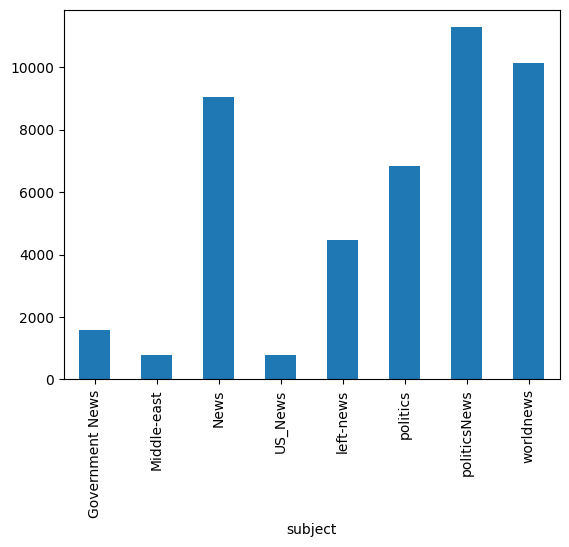

In [ ]:
# How many articles per subject?
print(data.groupby(['subject'])['text'].count())
data.groupby(['subject'])['text'].count().plot(kind="bar")
plt.show()

target
fake    23481
true    21417
Name: text, dtype: int64


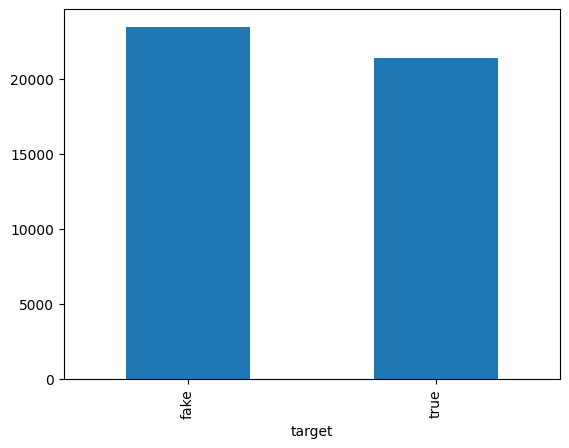

In [ ]:
# How many fake and real articles?
print(data.groupby(['target'])['text'].count())
data.groupby(['target'])['text'].count().plot(kind="bar")
plt.show()

In [ ]:
from nltk import tokenize

token_space = tokenize.WhitespaceTokenizer()

def counter(data, column_text, quantity):
    all_words = ' '.join([text for text in data[column_text]])
    token_phrase = token_space.tokenize(all_words)
    frequency = nltk.FreqDist(token_phrase)
    df_frequency = pd.DataFrame({"Word": list(frequency.keys()),
                                 "Frequency": list(frequency.values())})
    df_frequency = df_frequency.nlargest(columns="Frequency", n=quantity)

    plt.figure(figsize=(12, 8))
    ax = sns.barplot(data=df_frequency, x="Word", y="Frequency", color='blue')
    ax.set(ylabel="Count")
    plt.xticks(rotation='vertical')
    plt.title(f"Top {quantity} Most Frequent Words in '{column_text}' Column")
    plt.show()

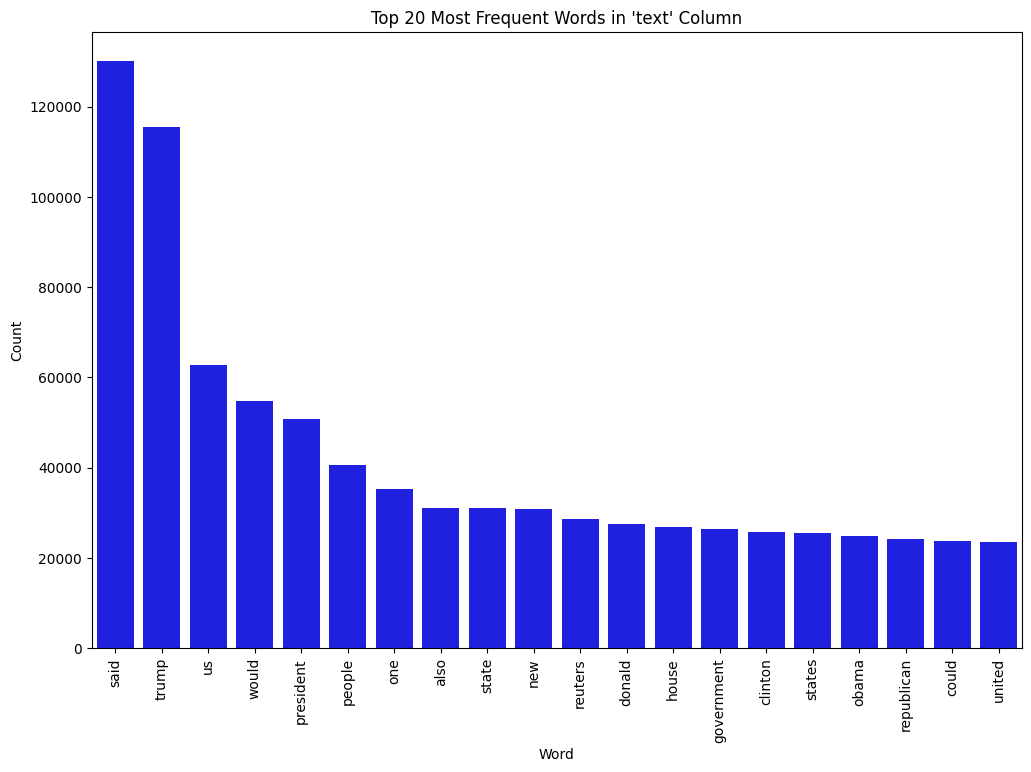

In [ ]:
counter(data, 'text', 20)

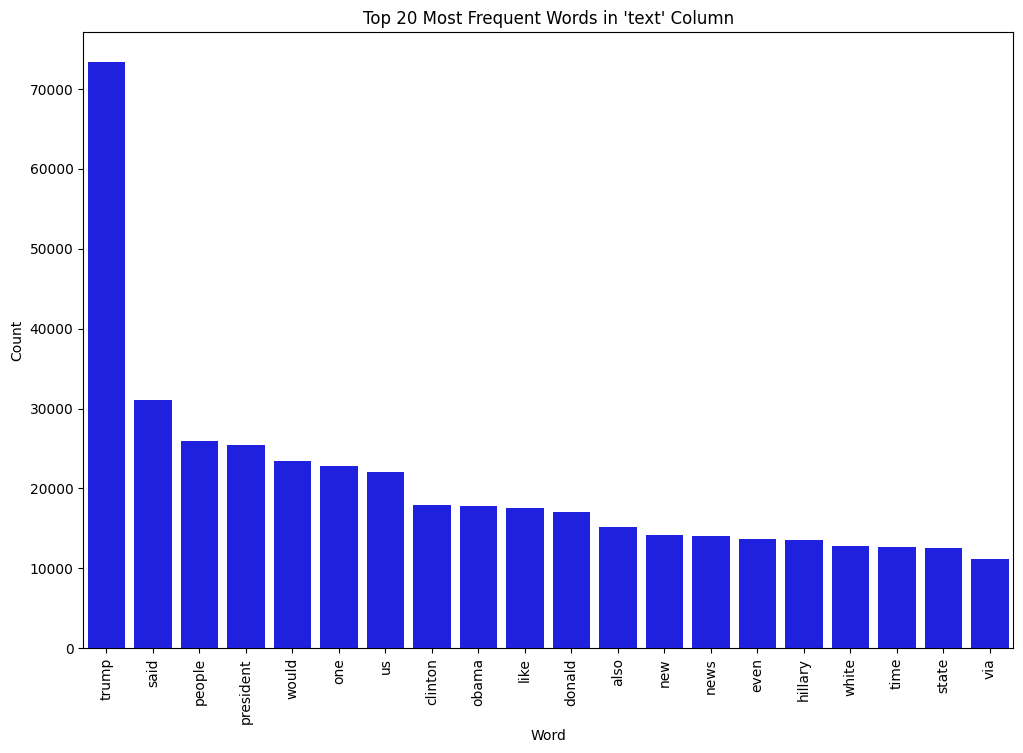

In [ ]:
counter(data[data["target"] == "fake"], "text", 20)

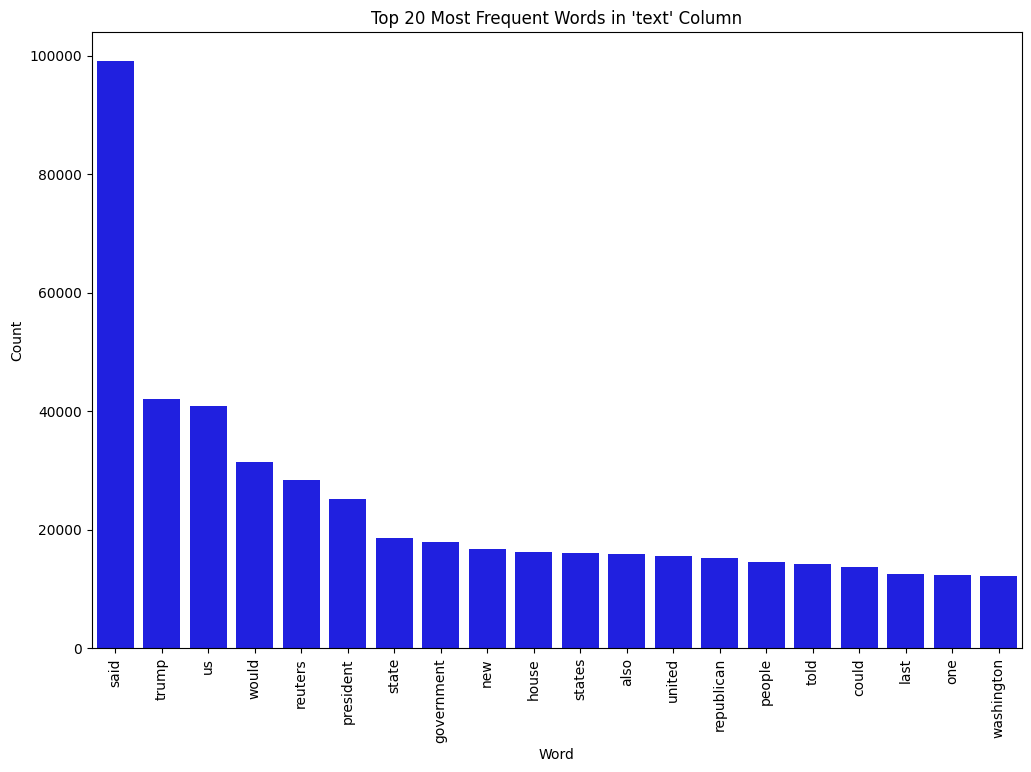

In [ ]:
# Most frequent words in real news
counter(data[data["target"] == "true"], "text", 20)

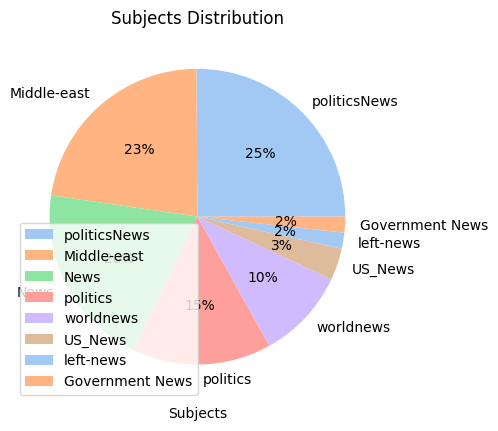

In [ ]:
import seaborn as sbs

df_top=data.copy()
df_top_group=df_top.subject.value_counts()
df_top_group

colors = sbs.color_palette('pastel')[0:6]
plt.pie(df_top_group,labels=df_top.subject.unique(),autopct='%.0f%%', colors=colors)
plt.title('Subjects Distribution')
plt.xlabel('Subjects')
plt.legend(df_top.subject.unique(), loc='lower left')
plt.show();

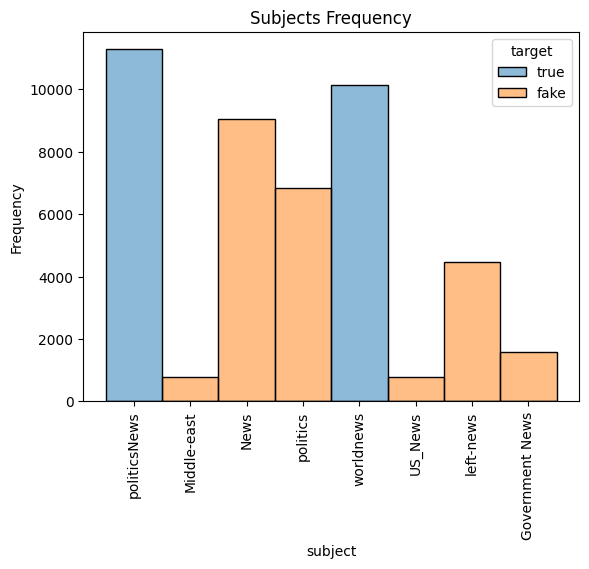

In [ ]:
top_parties = data['subject'].value_counts().nlargest(5).index
df_top=data.copy()
df_top.loc[~df_top['subject'].isin(top_parties), 'Party'] = 'Other'
sns.histplot(x='subject', hue='target', data=df_top, stat='count')
plt.title('Subjects Frequency')
plt.xticks(rotation=90)
plt.ylabel('Frequency')
plt.show();

MODELING

In [ ]:
import itertools
from sklearn import metrics

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], '.2f' if normalize else 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['target'], test_size=0.2, random_state=42)


NAIVE BAYES

In [ ]:
dct = dict()
from sklearn.naive_bayes import MultinomialNB
NB_classifier = MultinomialNB()
pipe = Pipeline([('vect', CountVectorizer()),
('tfidf', TfidfTransformer()),
('model', NB_classifier)])
model = pipe.fit(X_train, y_train)
prediction = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, prediction)*100,2)))
dct['Naive Bayes'] = round(accuracy_score(y_test, prediction)*100,2)

accuracy: 95.29%


In [ ]:

import joblib
# Save Naive Bayes model
joblib.dump(model, 'news_detector_nb_model.pkl')

'''
from google.colab import files
# Download Naive Bayes model
files.download('news_detector_nb_model.pkl')
'''

"\nfrom google.colab import files\n# Download Naive Bayes model\nfiles.download('news_detector_nb_model.pkl')\n"

Confusion matrix, without normalization
[[4379  275]
 [ 148 4178]]


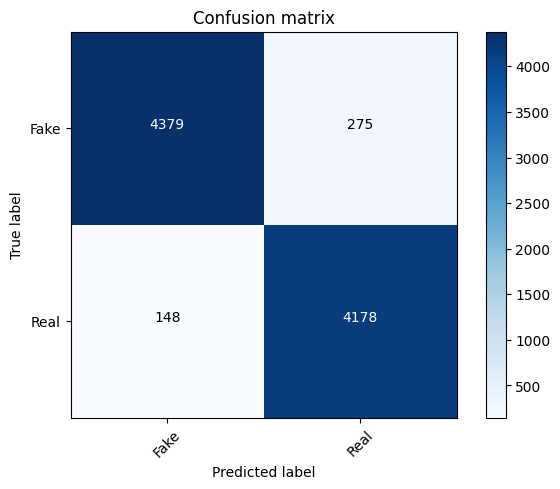

In [ ]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

LOGISTIC REGRESSION




In [ ]:
# Train Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import joblib
from google.colab import files

# Build pipeline
pipe_lr = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', LogisticRegression(max_iter=300, solver='lbfgs', random_state=42))
])

# Train the model
print("Training Logistic Regression model...")
lr_model = pipe_lr.fit(X_train, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test)
acc_lr = round(accuracy_score(y_test, y_pred_lr) * 100, 2)
print(f"Logistic Regression Accuracy: {acc_lr}%")




Training Logistic Regression model...
Logistic Regression Accuracy: 98.92%


In [ ]:
# Save & download
joblib.dump(lr_model, 'news_detector_lr_model.pkl')
print("Model saved as news_detector_lr_model.pkl")
files.download('news_detector_lr_model.pkl')

Model saved as news_detector_lr_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion matrix, without normalization
[[4608   46]
 [  51 4275]]

 Classification Report (Logistic Regression):

              precision    recall  f1-score   support

        fake       0.99      0.99      0.99      4654
        true       0.99      0.99      0.99      4326

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



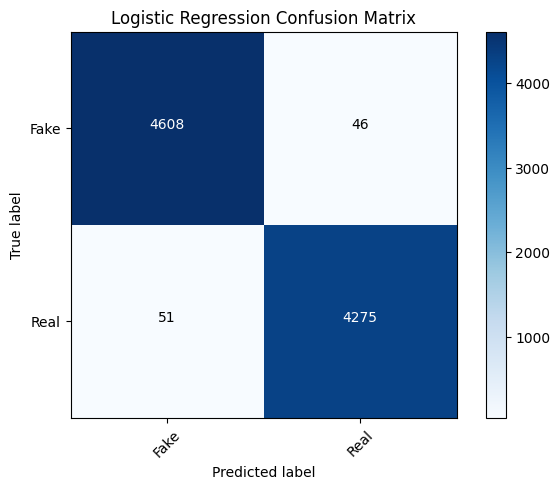

In [ ]:
from sklearn import metrics

cm_lr = metrics.confusion_matrix(y_test, y_pred_lr)
plot_confusion_matrix(cm_lr, classes=['Fake', 'Real'], title='Logistic Regression Confusion Matrix')

print("\n Classification Report (Logistic Regression):\n")
print(metrics.classification_report(y_test, y_pred_lr))


DECISION TREE

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Vectorizing and applying TF-IDF
pipe = Pipeline([('vect', CountVectorizer()),
('tfidf', TfidfTransformer()),
('model', DecisionTreeClassifier(criterion= 'entropy',
max_depth = 20,
splitter='best',
random_state=42))])

# Fitting the model
model = pipe.fit(X_train, y_train)
# Accuracy
prediction = model.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, prediction)*100,2)))
dct['Decision Tree'] = round(accuracy_score(y_test, prediction)*100,2)

accuracy: 99.7%


In [ ]:
import joblib
# Save Naive Bayes model
joblib.dump(model, 'news_detector_dt_model.pkl')

'''
from google.colab import files
# Download Naive Bayes model
files.download('news_detector_dt_model.pkl')
'''

"\nfrom google.colab import files\n# Download Naive Bayes model\nfiles.download('news_detector_dt_model.pkl')\n"

Confusion matrix, without normalization
[[4643   11]
 [  16 4310]]


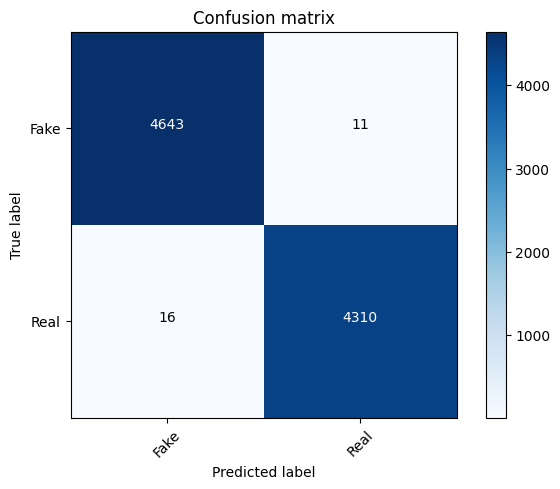

In [ ]:
cm = metrics.confusion_matrix(y_test, prediction)
plot_confusion_matrix(cm, classes=['Fake', 'Real'])

**CONCLUSION**:
In the 21st century, the majority of the tasks are done online. Newspapers that
were earlier preferred as hard-copies are now being substituted by applications
like Facebook, Twitter, and news articles to be read online. Whatsapp’s forwards
are also a major source. The growing problem of fake news only makes things more
complicated and tries to change or hamper the opinion and attitude of people
towards use of digital technology. When a person is deceived by the real news two possible things happen- People start believing that their perceptions about a particular topic are true as assumed. Thus, in order to curb the phenomenon, we have developed our Fake news Detection system that takes input from the user and classifies it to be true or fake. To implement this, various Machine Learning Techniques have to be used. The model is trained using an appropriate dataset and performance evaluation is also done using various performance measures. The best model, i.e. the model with highest accuracy is used to classify the news headlines or articles. The user can check the
news article or keywords online; he can also check the authenticity of the website.

In [ ]:
# Load the saved model
loaded_model = joblib.load('news_detector_nb_model.pkl')

# Example test input
sample_news = ["The government has announced new AI funding initiatives."]

# Make a prediction
prediction = loaded_model.predict(sample_news)
print("Prediction:", prediction[0])  # 'true' or 'fake'

# Get confidence scores for each class
probabilities = loaded_model.predict_proba(sample_news)

# Print probability for both classes
print("Confidence Scores:")
for label, score in zip(loaded_model.classes_, probabilities[0]):
    print(f"{label}: {score*100:.2f}%")

# Print the confidence for the predicted class only
confidence = max(probabilities[0]) * 100
print(f"\nModel confidence in prediction: {confidence:.2f}%")


Prediction: true
Confidence Scores:
fake: 9.23%
true: 90.77%

Model confidence in prediction: 90.77%


In [ ]:
# 🧠 Fake News Detector | Model Comparison Test
# Make sure you’ve uploaded:
#  - fake_news_nb_model.pkl
#  - fake_news_dt_model.pkl
# in your Colab working directory (/content)

import joblib
import pandas as pd

# Load both trained models
nb_model = joblib.load('news_detector_nb_model.pkl')
dt_model = joblib.load('news_detector_lr_model.pkl')

# Example test headlines/articles
news_samples = [
    # Real news
    "The Indian Space Research Organisation (ISRO) successfully launched its latest communication satellite GSAT-20 from the Satish Dhawan Space Centre on Friday morning.",
    "Apple announced new privacy features for iOS 18 at its annual developers’ conference, promising enhanced on-device data protection for users.",
    "The World Health Organization has declared that the global number of COVID-19 cases continues to decline for the seventh consecutive month.",
    # Fake / clickbait
    "21st Century Wire says Kellyanne Conway thrashed NBC s Chuck Todd around the set on Meet The Press when he tried to paint the Trump administration as releasing  false information  about their inauguration attendance numbers. Conway, like many viewers, immediately caught Todd in the fact that the topic was meaningless and was quick to point out a number of main stream media reports containing  falsehoods  that were pushed by establishment media. Conway hit her stride regarding the topic of inauguration attendance numbers when she told Chuck Todd,  Presidents aren t judged by crowd sizes at their inaugurations, they are judged by their accomplishments. When Todd hit back with a double down on the accusations that the comments by Trump Press Secretary, Sean Spicer, were put out there to push a  provable falsehood  Conway fired back with some choice phrases that have commentators on the edge of their seats. We re going to have to rethink our relationship with the media. you ve got a 14% approval rating, that you ve earned. . Read More 2016 Election News at: 21st Century Wire 2016 FilesSUPPORT 21WIRE   SUBSCRIBE & BECOME A MEMBER@ 21WIRE.TV",
    "Scientists reveal chocolate can cure all forms of cancer according to a new Harvard study.",
    "The government secretly replaced all streetlights with surveillance devices to monitor citizens’ conversations."
]

# Function to get predictions + confidence
def get_results(model, text_list):
    preds = model.predict(text_list)
    probs = model.predict_proba(text_list)
    confs = [round(max(p)*100, 2) for p in probs]
    return preds, confs

# Run both models
nb_preds, nb_confs = get_results(nb_model, news_samples)
dt_preds, dt_confs = get_results(dt_model, news_samples)

# Build comparison table
results = pd.DataFrame({
    "News Text": news_samples,
    "Naive Bayes Prediction": nb_preds,
    "Naive Bayes Confidence (%)": nb_confs,
    "Decision Tree Prediction": dt_preds,
    "Decision Tree Confidence (%)": dt_confs
})

# Determine which model was more confident
results["Chosen Model"] = [
    "Naive Bayes" if nb_confs[i] >= dt_confs[i] else "Decision Tree"
    for i in range(len(news_samples))
]

# Show results neatly
pd.set_option('display.max_colwidth', None)
print("🔎 Model Comparison Results:\n")
display(results)

# Quick summary counts
print("\n✅ Naive Bayes won for:", (results['Chosen Model'] == 'Naive Bayes').sum(), "samples")
print("🌳 Decision Tree won for:", (results['Chosen Model'] == 'Decision Tree').sum(), "samples")


🔎 Model Comparison Results:



,News Text,Naive Bayes Prediction,Naive Bayes Confidence (%),Decision Tree Prediction,Decision Tree Confidence (%),Chosen Model
0,The Indian Space Research Organisation (ISRO) successfully launched its latest communication satellite GSAT-20 from the Satish Dhawan Space Centre on Friday morning.,true,96.83,true,62.36,Naive Bayes
1,"Apple announced new privacy features for iOS 18 at its annual developers’ conference, promising enhanced on-device data protection for users.",true,95.01,fake,68.47,Naive Bayes
2,The World Health Organization has declared that the global number of COVID-19 cases continues to decline for the seventh consecutive month.,true,99.70,true,90.22,Naive Bayes
3,"21st Century Wire says Kellyanne Conway thrashed NBC s Chuck Todd around the set on Meet The Press when he tried to paint the Trump administration as releasing false information about their inauguration attendance numbers. Conway, like many viewers, immediately caught Todd in the fact that the topic was meaningless and was quick to point out a number of main stream media reports containing falsehoods that were pushed by establishment media. Conway hit her stride regarding the topic of inauguration attendance numbers when she told Chuck Todd, Presidents aren t judged by crowd sizes at their inaugurations, they are judged by their accomplishments. When Todd hit back with a double down on the accusations that the comments by Trump Press Secretary, Sean Spicer, were put out there to push a provable falsehood Conway fired back with some choice phrases that have commentators on the edge of their seats. We re going to have to rethink our relationship with the media. you ve got a 14% approval rating, that you ve earned. . Read More 2016 Election News at: 21st Century Wire 2016 FilesSUPPORT 21WIRE SUBSCRIBE & BECOME A MEMBER@ 21WIRE.TV",true,99.83,true,75.14,Naive Bayes
4,Scientists reveal chocolate can cure all forms of cancer according to a new Harvard study.,true,82.31,fake,76.60,Naive Bayes
5,The government secretly replaced all streetlights with surveillance devices to monitor citizens’ conversations.,true,96.51,fake,53.56,Naive Bayes



✅ Naive Bayes won for: 6 samples
🌳 Decision Tree won for: 0 samples


In [ ]:
# 🧠 Fake News Detector | Model Comparison Test
# Make sure you’ve uploaded:
#  - fake_news_nb_model.pkl
#  - fake_news_dt_model.pkl
# in your Colab working directory (/content)

import joblib
import pandas as pd

# Load both trained models
nb_model = joblib.load('news_detector_nb_model.pkl')
dt_model = joblib.load('news_detector_dt_model.pkl')

# Example test headlines/articles
news_samples = [

"One day after President Trump's inauguration, hundreds of thousands of people descended on Washington, D.C. for the Women's March, and many more took to the streets in cities across all 50 states as well as dozens of countries abroad. At the flagship march in D.C., a star-studded line up kicked off the day's events. Many marchers wore pink pussy hats, designed to reclaim the president's vulgar use of the term on the 2005 Access Hollywood tape. While organizers said the day was not about being anti-Trump, critics felt it excluded conservative women and would lead to little positive change. But for one day at least, the turnout was a massive show of solidarity among women (and men) across the globe.",

"Bombshell reports in October from The New York Times and The New Yorker exposed allegations of Harvey Weinstein's sexual misconduct in Hollywood. Although he has denied any nonconsensual encounters, dozens of women have accused the producer of sexual harassment and assault. The revelations revealed a deeply rooted problem in Hollywood and beyond of men using their power and influence to take advantage of women. As more women felt empowered to come forward, more prominent men lost their jobs -- including actor Kevin Spacey; comedian Louis C.K.; journalists Charlie Rose and Matt Lauer; and politicians Al Franken and John Conyers. This watershed moment sparked an ongoing national conversation about sexual misconduct and power dynamics in the workplace. The hashtag #MeToo went viral as millions of people took to social media to share their experiences",

"Hurricane season in 2017 was particularly brutal for the southeastern U.S. and Caribbean. Hurricane Harvey left a path of destruction in Houston and surrounding areas of Texas as well as Louisiana. Record-breaking downpours left entire towns underwater, including small farm communities like Winnie, Texas. The nation barely had time to rally around the victims before Hurricane Irma made landfall in Florida, also causing severe damage in Puerto Rico on the way. Then when Hurricane Maria made landfall in Puerto Rico at the end of September, power was knocked out to the entire U.S. territory and millions of residents -- who are U.S. citizens -- struggled to find clean drinking water and safe shelter. With communications down and major roadways destroyed, aid couldn't reach large portions of the population. Three months later, 30 percent of the island is still without electricity and nearly 250,000 people have sought refuge in Florida, CBS News' David Begnaud reports",


"U.S. intelligence agencies determined last year that Russians interfered with the presidential election. But the question lingers, was there any collusion with the Trump campaign? The resulting investigation has been a cloud hovering over the Trump administration since Day 1. Then-FBI Director James Comey was leading a probe into the matter when Trump suddenly fired him. As a result, special counsel Robert Mueller was appointed to oversee the investigation. Trump's former campaign chairman Paul Manafort and former national security advisor Michael Flynn have both been criminally charged (Flynn pleaded guilty), along with two other campaign aides. And let's not forget the time Donald Trump, Jr. tweeted out his email exchanges setting up a meeting with a Russian lawyer who claimed to have damaging information about Hillary Clinton. Trump and his team continue to insist there was no collusion with Russia, but the investigation is likely nowhere near over.",

"President Trump's administration has seen a considerable amount of high-profile staff turnover during its first year. The first to go was former national security advisor Mike Flynn in February, just 25 days into the term, after it was revealed he lied about his contact with the Russian government. He was also a registered foreign agent for the government of Turkey. He recently plead guilty to lying to the FBI. Next was James Comey's firing in May. Then, a whirlwind series of exits over the course of 10 days in July, when Anthony Scaramucci was brought in as the new communications director and press secretary Sean Spicer and chief of staff Reince Priebus quickly left the White House. Then Scaramucci himself got the boot after an explosive phone call to a high-profile journalist reportedly angered the new chief of staff, General John Kelly. Chief strategist  in August, returning to his post at Breitbart. In September, Health and Human Services Secretary Tom Price resigned over his use of private charter planes. Most recently, reality star Omarosa Manigualt Newman left her White House public liaison job, reportedly in dramatic fashion.",


"In a year that was particularly polarizing, the sun and moon provided a welcome distraction this summer when the solar eclipse captivated the nation. Millions of Americans traveled and camped out to be within the path of totality, which stretched from Oregon to South Carolina. Although the event itself only lasted for one hour and 33 minutes, the weeks and days of excitement leading up to it gave Americans something positive and uplifting to look forward to. Gone for a moment were the Twitter hot-takes and political bickering. The eclipse was just cool, and that's something we could all agree on -- even if only for a day.",

"In August, groups of neo-Nazis and white supremacists gathered in Charlottesville, Virginia to protest the removal of a statue of Robert E. Lee from a park at the University of Virginia. A rally was planned for Saturday, August 12th, but the night before hundreds of men marched through the school's grounds with tiki torches chanting phrases like Jews will not replace us and the Nazi slogan, blood and soil. The demonstration only foreshadowed the dark events of the next day, when the supremacist groups clashed violently with anti-fascists and counter-protesters. Police called off the event, and as protesters left the scene a white supremacist drove a car into the crowd, injuring dozens and killing a peaceful protester named Heather Heyer. The events of the weekend left the country shaken and searching for answers. When President Trump finally addressed what happened, his words did little to promote healing.  Trump said in a press conference three days later. He soon added there were very fine people on both sides. His choice of words ignited a firestorm of criticism, and left the country once again grappling with how to talk about race, bigotry, and the legacy of segregation in America today.",

"Colin Kaepernick's protest on the NFL sidelines had mostly faded from the national spotlight until September, when President Trump spoke about it at a rally in Alabama. Wouldn't you love to see one of these NFL owners, when somebody disrespects our flag, to say, Get that son of a b---- off the field right now,' Trump asked the crowd, which responded with loud cheers. Players, coaches, and team owners across the league denounced the president's statement and defended players' rights to express their views. The next weekend, the national anthem at the start of each game was almost more hyped than the games themselves. More than 200 NFL players kneeled in a show of solidarity. The Pittsburgh Steelers voted as a team to sit out the anthem all together, while the entire Dallas Cowboys lineup kneeled on the 50-yard line before their game began. In early October, Vice President Mike Pence left an Indianapolis Colts game after some players took a knee. He said it was a matter of patriotism and respect, but critics called it a taxpayer funded publicity stunt. Supporters of the kneeling protests say the gesture is intended to call attention to police brutality and the unequal treatment of black citizens in America, but detractors believe kneeling during the anthem is disrespectful to those who have fought and died for our country."
 ]

# Function to get predictions + confidence
def get_results(model, text_list):
    preds = model.predict(text_list)
    probs = model.predict_proba(text_list)
    confs = [round(max(p)*100, 2) for p in probs]
    return preds, confs

# Run both models
nb_preds, nb_confs = get_results(nb_model, news_samples)
dt_preds, dt_confs = get_results(dt_model, news_samples)

# Build comparison table
results = pd.DataFrame({
    "News Text": news_samples,
    "Naive Bayes Prediction": nb_preds,
    "Naive Bayes Confidence (%)": nb_confs,
    "Decision Tree Prediction": dt_preds,
    "Decision Tree Confidence (%)": dt_confs
})

# Determine which model was more confident
results["Chosen Model"] = [
    "Naive Bayes" if nb_confs[i] >= dt_confs[i] else "Decision Tree"
    for i in range(len(news_samples))
]

# Show results neatly
pd.set_option('display.max_colwidth', None)
print("🔎 Model Comparison Results:\n")
display(results)

# Quick summary counts
print("\n✅ Naive Bayes won for:", (results['Chosen Model'] == 'Naive Bayes').sum(), "samples")
print("🌳 Decision Tree won for:", (results['Chosen Model'] == 'Decision Tree').sum(), "samples")


🔎 Model Comparison Results:



,News Text,Naive Bayes Prediction,Naive Bayes Confidence (%),Decision Tree Prediction,Decision Tree Confidence (%),Chosen Model
0,"One day after President Trump's inauguration, hundreds of thousands of people descended on Washington, D.C. for the Women's March, and many more took to the streets in cities across all 50 states as well as dozens of countries abroad. At the flagship march in D.C., a star-studded line up kicked off the day's events. Many marchers wore pink pussy hats, designed to reclaim the president's vulgar use of the term on the 2005 Access Hollywood tape. While organizers said the day was not about being anti-Trump, critics felt it excluded conservative women and would lead to little positive change. But for one day at least, the turnout was a massive show of solidarity among women (and men) across the globe.",true,99.95,true,100.0,Decision Tree
1,"Bombshell reports in October from The New York Times and The New Yorker exposed allegations of Harvey Weinstein's sexual misconduct in Hollywood. Although he has denied any nonconsensual encounters, dozens of women have accused the producer of sexual harassment and assault. The revelations revealed a deeply rooted problem in Hollywood and beyond of men using their power and influence to take advantage of women. As more women felt empowered to come forward, more prominent men lost their jobs -- including actor Kevin Spacey; comedian Louis C.K.; journalists Charlie Rose and Matt Lauer; and politicians Al Franken and John Conyers. This watershed moment sparked an ongoing national conversation about sexual misconduct and power dynamics in the workplace. The hashtag #MeToo went viral as millions of people took to social media to share their experiences",true,99.44,fake,100.0,Decision Tree
2,"Hurricane season in 2017 was particularly brutal for the southeastern U.S. and Caribbean. Hurricane Harvey left a path of destruction in Houston and surrounding areas of Texas as well as Louisiana. Record-breaking downpours left entire towns underwater, including small farm communities like Winnie, Texas. The nation barely had time to rally around the victims before Hurricane Irma made landfall in Florida, also causing severe damage in Puerto Rico on the way. Then when Hurricane Maria made landfall in Puerto Rico at the end of September, power was knocked out to the entire U.S. territory and millions of residents -- who are U.S. citizens -- struggled to find clean drinking water and safe shelter. With communications down and major roadways destroyed, aid couldn't reach large portions of the population. Three months later, 30 percent of the island is still without electricity and nearly 250,000 people have sought refuge in Florida, CBS News' David Begnaud reports",true,99.98,fake,100.0,Decision Tree
3,"U.S. intelligence agencies determined last year that Russians interfered with the presidential election. But the question lingers, was there any collusion with the Trump campaign? The resulting investigation has been a cloud hovering over the Trump administration since Day 1. Then-FBI Director James Comey was leading a probe into the matter when Trump suddenly fired him. As a result, special counsel Robert Mueller was appointed to oversee the investigation. Trump's former campaign chairman Paul Manafort and former national security advisor Michael Flynn have both been criminally charged (Flynn pleaded guilty), along with two other campaign aides. And let's not forget the time Donald Trump, Jr. tweeted out his email exchanges setting up a meeting with a Russian lawyer who claimed to have damaging information about Hillary Clinton. Trump and his team continue to insist there was no collusion with Russia, but the investigation is likely nowhere near over.",true,99.99,fake,100.0,Decision Tree
4,"President Trump's administration has seen a considerable amount of high-profile staff turnover during its first year. The first to go was former national security advisor Mike Flynn in February, jus


✅ Naive Bayes won for: 0 samples
🌳 Decision Tree won for: 8 samples


In [ ]:
# 🧠 Fake News Detector | Model Comparison Test
# Make sure you’ve uploaded:
#  - fake_news_nb_model.pkl
#  - fake_news_dt_model.pkl
# in your Colab working directory (/content)

import joblib
import pandas as pd

# Load both trained models
nb_model = joblib.load('news_detector_nb_model.pkl')
dt_model = joblib.load('news_detector_dt_model.pkl')

# Example test headlines/articles
news_samples = [
    "President Obama has signed an executive order prohibiting students in public schools from reciting the Pledge of Allegiance, citing “religious inclusivity.” The order sparked outrage among conservative parents across the country."

"A historic German church was reduced to ashes after Muslim refugees set it on fire as part of a protest. Witnesses said the group shouted anti-Christian slogans before the blaze engulfed the building."

"A senior FBI agent involved in the Clinton email investigation was found dead in his home in Maryland, in what appears to be a murder-suicide. Officials say the agent, Michael Brown, had been under pressure after uncovering critical information about the case."

"In a shocking turn of events, Pope Francis has officially endorsed Donald Trump for President of the United States. The pontiff praised Trump as “a man of faith” and “the only leader who can defend Christianity around the world.” The Vatican’s spokesperson confirmed the endorsement earlier today."
  ]

# Function to get predictions + confidence
def get_results(model, text_list):
    preds = model.predict(text_list)
    probs = model.predict_proba(text_list)
    confs = [round(max(p)*100, 2) for p in probs]
    return preds, confs

# Run both models
nb_preds, nb_confs = get_results(nb_model, news_samples)
dt_preds, dt_confs = get_results(dt_model, news_samples)

# Build comparison table
results = pd.DataFrame({
    "News Text": news_samples,
    "Naive Bayes Prediction": nb_preds,
    "Naive Bayes Confidence (%)": nb_confs,
    "Decision Tree Prediction": dt_preds,
    "Decision Tree Confidence (%)": dt_confs
})

# Determine which model was more confident
results["Chosen Model"] = [
    "Naive Bayes" if nb_confs[i] >= dt_confs[i] else "Decision Tree"
    for i in range(len(news_samples))
]

# Show results neatly
pd.set_option('display.max_colwidth', None)
print("🔎 Model Comparison Results:\n")
display(results)

# Quick summary counts
print("\n✅ Naive Bayes won for:", (results['Chosen Model'] == 'Naive Bayes').sum(), "samples")
print("🌳 Decision Tree won for:", (results['Chosen Model'] == 'Decision Tree').sum(), "samples")


🔎 Model Comparison Results:



,News Text,Naive Bayes Prediction,Naive Bayes Confidence (%),Decision Tree Prediction,Decision Tree Confidence (%),Chosen Model
0,"President Obama has signed an executive order prohibiting students in public schools from reciting the Pledge of Allegiance, citing “religious inclusivity.” The order sparked outrage among conservative parents across the country.A historic German church was reduced to ashes after Muslim refugees set it on fire as part of a protest. Witnesses said the group shouted anti-Christian slogans before the blaze engulfed the building.A senior FBI agent involved in the Clinton email investigation was found dead in his home in Maryland, in what appears to be a murder-suicide. Officials say the agent, Michael Brown, had been under pressure after uncovering critical information about the case.In a shocking turn of events, Pope Francis has officially endorsed Donald Trump for President of the United States. The pontiff praised Trump as “a man of faith” and “the only leader who can defend Christianity around the world.” The Vatican’s spokesperson confirmed the endorsement earlier today.",true,99.96,true,100.0,Decision Tree



✅ Naive Bayes won for: 0 samples
🌳 Decision Tree won for: 1 samples


In [ ]:
# --- Model Comparison: Naive Bayes vs Logistic Regression ---

import joblib
import pandas as pd
import numpy as np

# Load trained models
nb_model = joblib.load('news_detector_nb_model.pkl')
lr_model = joblib.load('news_detector_lr_model.pkl')

# Define sample news articles
true_news = [
    "Bombshell reports in October from The New York Times and The New Yorker exposed allegations of Harvey Weinstein's sexual misconduct in Hollywood. Although he has denied any nonconsensual encounters, dozens of women have accused the producer of sexual harassment and assault. The revelations revealed a deeply rooted problem in Hollywood and beyond of men using their power and influence to take advantage of women. As more women felt empowered to come forward, more prominent men lost their jobs -- including actor Kevin Spacey; comedian Louis C.K.; journalists Charlie Rose and Matt Lauer; and politicians Al Franken and John Conyers. This watershed moment sparked an ongoing national conversation about sexual misconduct and power dynamics in the workplace. The hashtag #MeToo went viral as millions of people took to social media to share their experiences.",

    "Hurricane season in 2017 was particularly brutal for the southeastern U.S. and Caribbean. Hurricane Harvey left a path of destruction in Houston and surrounding areas of Texas as well as Louisiana. Record-breaking downpours left entire towns underwater, including small farm communities like Winnie, Texas. The nation barely had time to rally around the victims before Hurricane Irma made landfall in Florida, also causing severe damage in Puerto Rico on the way. Then when Hurricane Maria made landfall in Puerto Rico at the end of September, power was knocked out to the entire U.S. territory and millions of residents -- who are U.S. citizens -- struggled to find clean drinking water and safe shelter. With communications down and major roadways destroyed, aid couldn't reach large portions of the population. Three months later, 30 percent of the island is still without electricity and nearly 250,000 people have sought refuge in Florida, CBS News' David Begnaud reports."
]

fake_news = [
    "In a shocking turn of events, Pope Francis has officially endorsed Donald Trump for President of the United States. The pontiff praised Trump as “a man of faith” and “the only leader who can defend Christianity around the world.” The Vatican’s spokesperson confirmed the endorsement earlier today.",

    "A senior FBI agent involved in the Clinton email investigation was found dead in his home in Maryland, in what appears to be a murder-suicide. Officials say the agent, Michael Brown, had been under pressure after uncovering critical information about the case."
]

# Combine and label
test_texts = true_news + fake_news
labels = ["true", "true", "fake", "fake"]

# Create DataFrame to store results
results = []

for i, text in enumerate(test_texts):
    # Naive Bayes predictions
    nb_pred = nb_model.predict([text])[0]
    nb_prob = nb_model.predict_proba([text])[0]
    nb_conf = round(np.max(nb_prob) * 100, 2)

    # Logistic Regression predictions
    lr_pred = lr_model.predict([text])[0]
    lr_prob = lr_model.predict_proba([text])[0]
    lr_conf = round(np.max(lr_prob) * 100, 2)

    # Choose model with higher confidence
    if lr_conf > nb_conf:
        chosen_model = "Logistic Regression"
    else:
        chosen_model = "Naive Bayes"

    results.append({
        "News Text": text[:120] + "...",
        "Actual Label": labels[i],
        "Naive Bayes Prediction": nb_pred,
        "Naive Bayes Confidence (%)": nb_conf,
        "Logistic Regression Prediction": lr_pred,
        "Logistic Regression Confidence (%)": lr_conf,
        "Chosen Model": chosen_model
    })

# Display results neatly
df_results = pd.DataFrame(results)
print("🔎 Model Comparison Results:\n")
print(df_results.to_string(index=False))

# Count model wins
nb_wins = sum(df_results["Chosen Model"] == "Naive Bayes")
lr_wins = sum(df_results["Chosen Model"] == "Logistic Regression")

print("\n✅ Naive Bayes won for:", nb_wins, "samples")
print("🤖 Logistic Regression won for:", lr_wins, "samples")


🔎 Model Comparison Results:

                                                                                                                  News Text Actual Label Naive Bayes Prediction  Naive Bayes Confidence (%) Logistic Regression Prediction  Logistic Regression Confidence (%) Chosen Model
Bombshell reports in October from The New York Times and The New Yorker exposed allegations of Harvey Weinstein's sexual...         true                   true                       99.44                           true                               70.03  Naive Bayes
Hurricane season in 2017 was particularly brutal for the southeastern U.S. and Caribbean. Hurricane Harvey left a path o...         true                   true                       99.98                           true                               88.97  Naive Bayes
In a shocking turn of events, Pope Francis has officially endorsed Donald Trump for President of the United States. The ...         fake                   true        